<a href="https://colab.research.google.com/github/dagmaros27/AIMS_Notebooks/blob/main/sampling_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import matplotlib
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# for convenience
Fs = np.fft.fftshift
iFs = np.fft.ifftshift
FFT = np.fft.fft
iFFT = np.fft.ifft

# Efficient matrix vector products with Toeplitz matrices

To implement the matrix vector product in $\mathcal{O}(n\log n)$ we need to convert the Toeplitz matrix to a circulant matrix and use th efact that the eigenvectors of circulant matrices are the roots of unity i.e. correspond to columns of the matrix operator imeplementing the discrete Fourier transform. So if $C$ is a circulant matrix, we have that

$$ C = F^\dagger \hat{C} F, $$

where $F$ is the matrix implementing the DFT and $\hat{C}$ is a diagonal matrix containing the eigenvalues $\hat{c}$ on its diagonal. To get the eigenvalues we note that, since a column, $F_k$ say, of $F$ is an eigenvector of $C$, we have that

$$ C F_k = \hat{c}_k F_k.  $$

Thus, if $c$ is the first row or column of $C$, we can obtain $\hat{c}$

$$ \hat{c} = F c. $$

In [ ]:
sigmaf = 1.0
l = 0.1
n = 100
t = np.linspace(0, 1, n)

# covariance function
def cov_func(t, tp, sigmaf, l):
    r = np.abs(t - tp)
    return sigmaf**2 * np.exp(-r**2/(2*l**2))
    # return sigmaf**2 * (1 + np.sqrt(3)*r/l)*np.exp(-np.sqrt(3)*r/l)

# the covariance matrix can be computed using
def cov_mat(t, sigmaf, l):
    n = t.size
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            K[i, j] = cov_func(t[i], t[j], sigmaf, l)

    return K

K = cov_mat(t, sigmaf, l)

# we can turn a Toeplitz matrix into a circulant matrix using the following vector
def circ_vec(K):
    # The first column
    col = K[:, 0].copy()

    # The first row
    row = K[0, :].copy()  # technically this is the same as the first column because K is real and Hermitian (symmetric)
    return np.concatenate((col, col[1:-1][::-1]))
    # return np.concatenate((col, row[1:-1][::-1]))
    # return np.concatenate((col, col[1:-1].conj()[::-1]))

c = circ_vec(K)

def matvec(c, x):
    # pad input vector to the same size as c
    n = x.size
    npad = c.size - n
    xpad = np.pad(x, (0, npad), mode='constant')

    # get the FFT of both
    xhat = FFT(xpad)
    chat = FFT(c)  # we could technically pre-compute this

    return iFFT(chat * xhat)[0:n].real

# test the implementation
xi = np.random.randn(n)

res1 = K.dot(xi)
res2 = matvec(c, xi)

# these should be the same
print(np.abs(res1 - res2).max())





6.661338147750939e-15


# Samples using the Cholesky factor

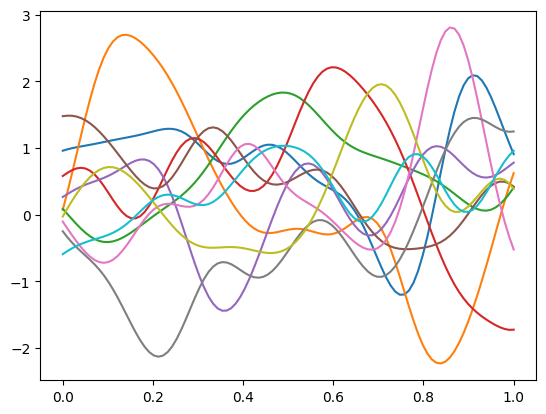

In [ ]:
# Cholesky based sampling
def sample_chol(L, nsamp=10):
    n = L.shape[0]
    xi = np.random.randn(n, nsamp)
    return L.dot(xi)

L = np.linalg.cholesky(K + 1e-10*np.eye(n))
samps = sample_chol(L)
plt.plot(t, samps)
plt.show()

# making sigmaf larger/smaller increases/decreases the variance
# making l larger/smaller makes the fluctuations slower/faster

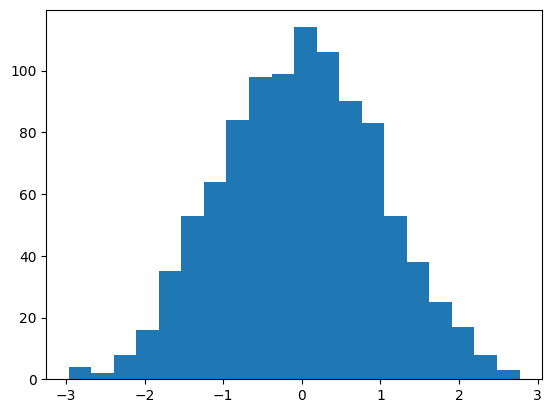

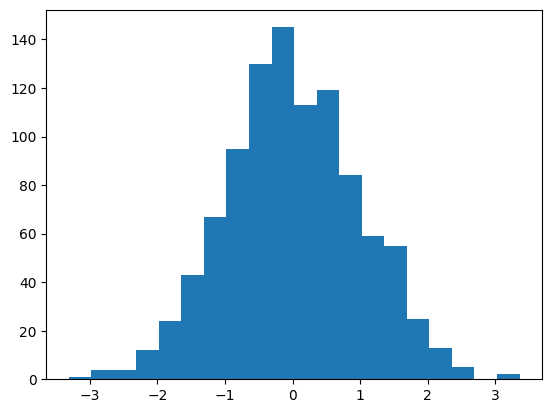

(100, 1000)


In [ ]:
samps = sample_chol(L, nsamp=1000)

def plot_hist(samps):

    plt.figure(1)
    plt.hist(samps[0, :], bins=20)

    plt.figure(2)
    plt.hist(samps[-1, :], bins=20)

    plt.show()

plot_hist(samps)
print(samps.shape)
# The distributions are Gaussian

# FFT based samples

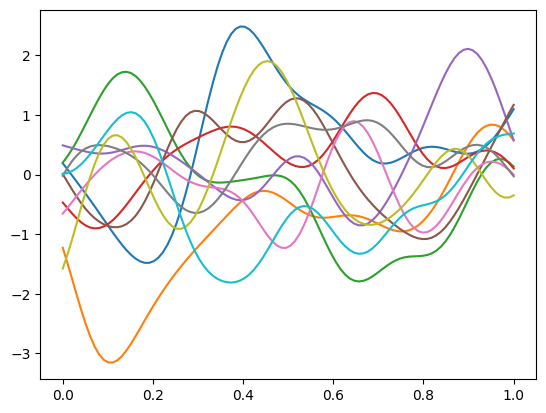

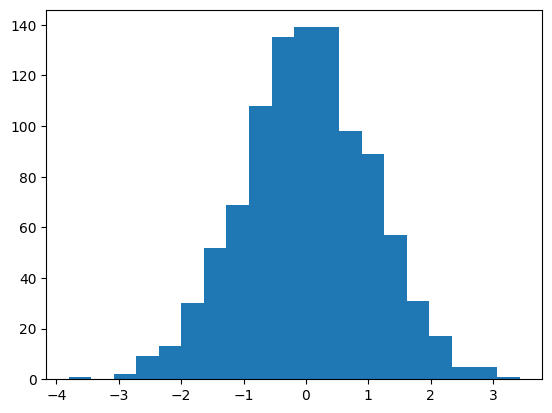

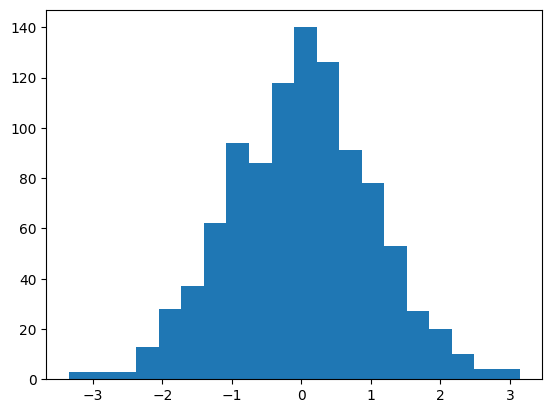

In [ ]:
# FFT based sampling
def sample_fft(c, nsamp=10):
    n = (c.size+2)//2
    pspec = np.abs(FFT(c))
    xi = np.random.randn(c.size, nsamp)
    xihat = FFT(xi, axis=0)

    return iFFT(xihat* np.sqrt(pspec)[:, None], axis=0)[0:n].real

samps = sample_fft(c, nsamp=1000)

# the samples get jagged as l tends to the size of the domain
# this is a limitation of the FFT based sampling method
plt.plot(t[:, None], samps[:, 0:10])
plt.show()

plot_hist(samps)

# Samples from power spectra

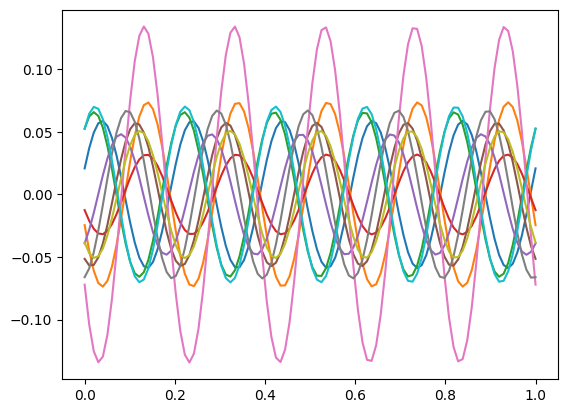

In [ ]:
# sampling from an arbitrary power spectrum

# first define the power spectrum
def power_spectrum(k):
    # return 1/(1+k**2)
    # tmp = 1/(1+k**8)  # np.zeros(k.size)
    tmp = np.zeros(k.size)
    # tmp[100] = 1.0
    tmp[10] = 1.0
    return tmp

# we need to know what the FFT frequencies are on the padded grid
L = 1                           # we want to evaluate on domain length D=[0,L].
cell = t[1]-t[0]                # cell size
kmax = 1.0/cell                 # max freq in Fourier domain required to accurately reconstruct signal at resolution of cell
dk = 1.0/(2*L)                  # k-grid spacing at Nyquist (volume factor)
m = int(np.ceil(kmax/dk))       # number of grid points in k-space
m = m+1 if m%2 else m           # as an even integer
k = np.arange(-(m//2), m//2)*dk # the k grid
# you could also get these using np.fft.fftfreq
knp = np.fft.fftfreq(m, d=cell)
assert (iFs(k) - knp == 0).all()

# sqrt of power spectrum required for sampling
pspec = power_spectrum(iFs(k))    # iFs because that's how np expects them to be ordered
pspec_sqrt = np.sqrt(pspec)


def sample_pspec(pspec_sqrt, nsamp=10):
    m = pspec_sqrt.size
    xi = np.random.randn(m, nsamp)
    xihat = FFT(xi, axis=0)
    return iFFT(xihat* pspec_sqrt[:, None], axis=0)[0:n].real


samps = sample_pspec(pspec_sqrt, nsamp=10)

plt.plot(t[:, None], samps)
plt.show()

# Assignment 2

## Q1

a) The probablity that a person's birthday falls on any given day of the year is

$$ p = \frac{1}{365}  $$

The probability that exactly $q$ out of $k$ people have their birthdays on 1 January is given by the Binomial probability density

$$ P(q|k,p,d=1Jan) = \frac{k!}{q!(k-q)!} p^q(1-p)^{(k-q)}  $$

The probability that up to $q$ people have their birthdays on the same day can be interpreted as, "What is the probabilty that $P(0|k,p,d=1Jan)$ or $P(1|k,p,d=1Jan)$ or $P(2|k,p,d=1Jan)$" and so on until we get to $q$. Because of the or we need to take the sum over the individual probabilties so

$$ P(up~to~q|k,p,d=1Jan) = \sum_{m=0}^q P(m|k,p,d=1Jan) $$

Similarly, the probability that at least $q$ people have their birthdays on the same day can be interpreted as, "What is the probabilty that $P(q|k,p,d=1Jan)$ or $P(q+1|k,p,d=1Jan)$ or $P(q+2|k,p,d=1Jan)$" and so on until we get to $k$. Thus

$$ P(at~least~q | k,p, d=1 Jan) = \sum_{m=q}^k P(m|k,p,d=1Jan) = \sum_{m=q}^k \frac{k!}{m!(k-m)!} p^m(1-p)^{(k-m)} $$

b) It might be tempting to substitute $q=2$ above to get the result but that does not account for the fact that the birthdays don't have to fall on 1 January, they can be on any day of the year. Attempts at using the above to answer the question get complicated because we can't assume sampling with replacement

The problem is easier if we start by asking, "What is the probablity that each of the $k$ people have different birthdays". Choosing one person at random, they can have their probability on any of the 365 days so there are 365 choices. The next person can their birthday on any other day than the first so there are only 364 choices left. The next person can have their birthday on any other day than the first two so there are 363 choices left and so on. To interpret these as probabilities we need to divide by the total number of choices so we have $\frac{365}{365}$ and $\frac{364}{365}$ and $\frac{363}{365}$ and so on. The fact that all of these events must happen simulataneously (i.e. we use and not or) means we multiply the individual probabilities i.e.

$$ P(k~all~different) = \prod_{m=2}^k \frac{365 - (m-1)}{365}  $$

The complement of the above is the probability of at least two people having their birthdays on the same day. In other words, the probablity that at least two people share a birthday or that all have different birthdays must be one. Thus

$$ P(at~least~2) = 1 - P(k~all~different) = 1 - \prod_{m=2}^k \frac{365 - (m-1)}{365} $$

c) We can write this probability as a function of k as follows

In [ ]:
def birthday_probability_at_least_2_any_day(k):
    probs = [(365 - (m-1))/(365) for m in range(2, k+1)]  # range must include k
    return 1 - np.prod(np.array(probs))

prob = 0
k = 0
while prob < 0.5:
    prob = birthday_probability_at_least_2_any_day(k)
    print(f"Probability for {k}:", prob)
    k += 1

Thus the solution is for $k=23$ we have a larger than 50% probability that two people share the same birthday. Let us compare this to the naive approach

In [ ]:
import math

q = 2   # Number of people we want to have birthday on January 1st

# equivalent to scipy.stats.binom.pmf
def binomial_pmf(k, q, p):
    return math.comb(k, q) * p**q * (1-p)**(k-q)

def birthday_probability_at_least_q_1Jan(k, q, p):
    probs = [binomial_pmf(k, i, p) for i in range(q, k+1)]
    return sum(probs)

# this is equivalent to the above
def birthday_probability_at_least_q_1Jan_complement(k, q, p):
    probs = [binomial_pmf(k, i, p) for i in range(0, q)]
    return 1 - sum(probs)

prob = 0
k = 0
while prob < 0.5:
    prob = birthday_probability_at_least_q_1Jan(k, q, 1/365) * 365
    print(f"Probability for {k}:", prob)
    k += 1

This gives slightly the wrong answer of $k=20$.

## Q2

a) We want to write this as a linear function of the form

$$ d = Rs + n $$

Stacking vectors such that $d = [d_1, d_2, d_3]^T$, $s = [s_1, s_2, s_3]^T$ and $n = [n_1, n_2, n_3]^T$ we have

$$ R = \begin{bmatrix}
        1 & -1 & 0 \\
        0 & 1 & -1 \\
        -1 & 0 & 1
        \end{bmatrix}  $$

Also noting that

$$ S = \frac{1}{\sigma^2} = N $$

we can use the solution to the first question of assignment 1 to get the posterior covariance as

$$ D = (R^\dagger N^{-1} R + S^{-1})^{-1}  $$

and a posetrior mean of

$$ m = D R^\dagger N^{-1} d $$

which we can compute symbolically using sympy as shown below.

In [ ]:
import sympy as sm
from sympy import init_printing
init_printing(use_latex=True, wrap_line=True)

sigma, d1, d2, d3 = sm.symbols('\sigma d_1 d_2 d_3')

R = sm.Matrix([[1, -1, 0], [0, 1, -1], [-1, 0, 1]])
d = sm.Matrix([[d1], [d2], [d3]])
Sinv = sm.Matrix([[sigma**2, 0, 0], [0, sigma**2, 0], [0, 0, sigma**2]])
Ninv = sm.Matrix([[sigma**2, 0, 0], [0, sigma**2, 0], [0, 0, sigma**2]])

Dinv = R.T * Ninv * R + Sinv
D = Dinv.inv()

# use sympy to print
D

⎡    1          1          1    ⎤
⎢─────────  ─────────  ─────────⎥
⎢        2          2          2⎥
⎢2⋅\sigma   4⋅\sigma   4⋅\sigma ⎥
⎢                               ⎥
⎢    1          1          1    ⎥
⎢─────────  ─────────  ─────────⎥
⎢        2          2          2⎥
⎢4⋅\sigma   2⋅\sigma   4⋅\sigma ⎥
⎢                               ⎥
⎢    1          1          1    ⎥
⎢─────────  ─────────  ─────────⎥
⎢        2          2          2⎥
⎣4⋅\sigma   4⋅\sigma   2⋅\sigma ⎦

In [ ]:
# now the mean
m = D * R.T * Ninv * d

m

⎡ d₁   d₃ ⎤
⎢ ── - ── ⎥
⎢ 4    4  ⎥
⎢         ⎥
⎢  d₁   d₂⎥
⎢- ── + ──⎥
⎢  4    4 ⎥
⎢         ⎥
⎢  d₂   d₃⎥
⎢- ── + ──⎥
⎣  4    4 ⎦

The posterior is completely determined by this mean and covariance and takes the form

$$ p(s | d) = \frac{1}{\sqrt{(2\pi)^m |D|}} \exp\left(-\frac{1}{2}(x - m)^\dagger D^{-1} (x-m) \right)  $$


## Q3

From what the guide tells us we can set priors of

$$ P(w_i=s) = 0.8, \quad  P(w_i=c) = 0.2  $$

We are also given that

$$ P(w_{i+1}=c|w_i=s) = 0.1, \quad P(w_{i+1}=s|w_i=c) = 0.4 $$

a) You arrive on a sunny day and we want to know the probability that it was cloudy the day before. Hence we want

$$ P(w_{i-1}=c | w_i=s)  $$

We can use Bayes law to write this probabilty as

$$ P(w_{i-1}=c | w_i=s)  = \frac{P(w_i=s | w_{i-1}=c) P(w_{i-1}=c) }{\sum_{w_i \in (s, c)} P(w_i=s | w_{i-1}) p(w_{i-1})}  $$

where the denomenator $P(w_i=s)$ is distinct from the prior because the prior pertains to the day before.
To compute this we need to note that either the weather changes or it doesn't i.e.

$$ P(w_{i+1}=c|w_i=s) + P(w_{i+1}=s|w_i=s) = 1 \quad \rightarrow \quad P(w_{i+1}=s|w_i=s) = 0.9 $$

Substituting the numbers gives

$$ P(w_{i-1}=c | w_i=s)  = \frac{0.4 \times 0.2}{0.9 \times 0.8 + 0.4 \times 0.2} = 0.1  $$

so the probability that it was cloudy the day before is 10%

b) The probability that the weather changes is given by $P(w_{i+1} \neq w_i)$ and this can be computed using the sum rule

$$ P(w_{i+1} \neq w_i) = P(w_{i+1}=s | w_i=c)P(w_i=c) + P(w_{i+1}=c | w_i=s)P(w_i=s)  $$

which evaluates to

$$ P(w_{i+1} \neq w_i) = 0.4 \times 0.2 + 0.1 \times 0.8 = 0.16  $$

i.e. there is a 16% chance that the weather will change on any given day.

c) We want to know what is the probability of sunshine the following day i.e.

$$ P(w_{i+1}=s | forecast) = ? $$

We can compute this by marginalising the joint density

$$ P(w_{i+1}=s, w_i | forecast) = P(w_{i+1}=s| w_i) P(w_i | forecast) $$

over $w_i$. Since $w_i$ can only take values of $s$ or $c$ we have

$$ P(w_{i+1}=s | forecast) = P(w_{i+1}=s | w_i=s) P(w_i=s | forecast) + P(w_{i+1}=s | w_i=c) P(w_i=c | forecast) $$

We have been told that the forecast for a sunny day is

$$ P(w_i=s|forecast) = p_i  $$

This also means that the forecast that it is not a sunny day (i.e. a cloudy day) is

$$ P(w_i=c|forecast) = 1 - p_i  $$

Thus we have

$$ P(w_{i+1}=s | forecast) = 0.9 p_i + 0.4 (1 - p_i) = 0.4 + 0.5 p_i  $$

d) To answer this question we want to know what is the value of $p_i$ above as $i \rightarrow \infty$ i.e.

$$ p_\infty = 0.4 + 0.5 p_\infty  $$

Solving for $p_\infty$ gives

$$ p_\infty = 0.8 $$

so the travel guide was correct.



So let us begin be deriving an expression for it. Anticipating that we are going to use a Gaussian integral, we start by solving for $C$ above. Noting that the quadratic and linear terms in $x$ will cancel by construction, we have that

$$ \bar{x}^\dagger D^{-1} \bar{x} + C = y^\dagger \Sigma^{-1} y. $$

In terms of the original quatities, we have

$$ C = y^\dagger\left(\Sigma^{-1} - \Sigma^{-1} (K^{-1} + \Sigma^{-1})^{-1} \Sigma^{-1} \right) y.   $$

We can again use the matrix inversion lemma to simplify this to

$$ C = y^\dagger K_y^{-1} y $$

We can now write out the full expression for the joint density as

$$ p(y, x) = \frac{\exp(-\frac{C}{2})}{\sqrt{(2\pi)^n |K|} \sqrt{(2\pi)^n |\Sigma|}} \exp\left(-\frac{1}{2}(x - \bar{x})^\dagger D^{-1} (x - \bar{x})\right)   $$

which we can integrate to find the expression for the marginal likelihood

$$ p(y) = \int p(y, x) dx = \frac{\exp(-\frac{C}{2})}{\sqrt{(2\pi)^n |K|} \sqrt{(2\pi)^m |\Sigma|}} \sqrt{(2\pi)^n |D|} $$

substituting in terms of original quantities and using the fact that $|A^{-1}| = 1/|A|$ gives the full expression

$$ p(y) = \int p(y, x) dx = \frac{\exp(-\frac{1}{2}y^\dagger\left(\Sigma^{-1} - \Sigma^{-1} R(K^{-1} + R^\dagger \Sigma^{-1} R)^{-1} R^\dagger \Sigma^{-1} \right) y))}{\sqrt{(2\pi)^m |K| |\Sigma| |R^\dagger \Sigma^{-1} R + K^{-1}|}} $$

While this expression is not pretty, it can in principle be used to adapt the prior to the problem at hand (this is sometimes called critical Wiener filtering). In practise, however, this is complicated by the presence of determinants which are costly to compute making it an impractical solution for large signals.